# **SQL within R and R Analytics**

This notebook focuses on SQL-based querying and analytical processing within the R environment for the NorthStar Urban Mobility and Logistics case study. SQL within R was used to filter, join, aggregate, and analyse structured operational datasets in order to investigate the causes of delivery failures, delays, customer complaints, and operational inefficiencies.

The analysis combines SQL querying using sqldf() with R analytical and visualisation techniques to identify operational patterns across hubs, drivers, vehicles, routing behaviour, complaints, and delivery performance. R libraries including dplyr, ggplot2, lubridate, and tidyr were used for data cleaning, statistical analysis, trend identification, and visual reporting.

The objective of this notebook is to demonstrate how SQL and R analytics can be integrated to support operational analysis, performance evaluation, and business decision-making using structured logistics and mobility datasets.

# **Environment Setup and Data Loading**

Install and Load Required Libraries

In [ ]:
# Install packages
install.packages(c(
  "sqldf",
  "dplyr",
  "ggplot2",
  "lubridate",
  "tidyr"
), quiet = TRUE)

# Load libraries
library(sqldf)
library(dplyr)
library(ggplot2)
library(lubridate)
library(tidyr)

cat("Libraries loaded successfully")

Libraries loaded successfully

In [ ]:
# Dataset loaded from GitHub
base_url <- "https://raw.githubusercontent.com/Neha-Savahir/northstar-analysis/refs/heads/main/northstar_dataset/"

# Load datasets
customers       <- read.csv(paste0(base_url, "customers.csv"))
orders          <- read.csv(paste0(base_url, "orders.csv"))
deliveries      <- read.csv(paste0(base_url, "deliveries.csv"))
drivers         <- read.csv(paste0(base_url, "drivers.csv"))
vehicles        <- read.csv(paste0(base_url, "vehicles.csv"))
hubs            <- read.csv(paste0(base_url, "hubs.csv"))
incidents       <- read.csv(paste0(base_url, "incidents.csv"))
complaints      <- read.csv(paste0(base_url, "complaints.csv"))
app_events      <- read.csv(paste0(base_url, "app_events.csv"))
data_dictionary <- read.csv(paste0(base_url, "data_dictionary.csv"))

cat("Datasets loaded successfully")

Datasets loaded successfully

# **Data Cleaning and Preparation**

### Standardise Zone Names

In [ ]:
# Function to standardise text
clean_text <- function(x) {
  tolower(trimws(as.character(x)))
}

# Apply cleaning
orders$pickup_zone <- clean_text(orders$pickup_zone)
orders$dropoff_zone <- clean_text(orders$dropoff_zone)

drivers$base_zone <- clean_text(drivers$base_zone)

vehicles$assigned_zone <- clean_text(vehicles$assigned_zone)

customers$home_zone <- clean_text(customers$home_zone)

hubs$zone <- clean_text(hubs$zone)

### Standardise Delivery Status

In [ ]:
deliveries$delivery_status <- tolower(trimws(deliveries$delivery_status))

table(deliveries$delivery_status)


delayed  failed  ontime 
    202     132     616 

### Convert Important Columns

In [ ]:
# Convert numeric fields
vehicles$battery_health_pct <- as.numeric(vehicles$battery_health_pct)

complaints$compensation_amount <- as.numeric(
  complaints$compensation_amount
)

# Convert date columns
orders$order_created_at <- ymd_hms(orders$order_created_at)

complaints$created_at <- ymd_hms(complaints$created_at)

### Handle missing values

In [ ]:
# Handle missing values in driver performance variables
drivers <- drivers %>%
  filter(!is.na(training_score),
         !is.na(driver_rating))

In [ ]:
# Handle missing values in vehicle battery health
vehicles <- vehicles %>%
  filter(!is.na(battery_health_pct))

### Check Missing Values

In [ ]:
colSums(is.na(vehicles))

colSums(is.na(complaints))

vehicle_id       vehicle_type      assigned_zone    commission_date 
                 0                  0                  0                  0 
battery_health_pct        odometer_km maintenance_status telematics_version 
                 0                  0                  0                  0

complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16

**Interpretation**

* Zone names were inconsistent in formatting (e.g., "North", "NORTH", "north"), which would have led to incorrect grouping in SQL analysis, and have now been standardised.
* The vehicles dataset previously contained missing values in battery health percentage, which have been handled during cleaning to ensure accurate performance analysis.
* The complaints dataset has missing compensation values, which could impact financial analysis and summaries.
* The drivers dataset also contains missing values in training scores and ratings, which were removed to ensure accurate performance analysis and correlation results.
* Delivery status values require standardisation to ensure consistent grouping and accurate reporting.
* Without cleaning, SQL-based aggregation would produce misleading or inconsistent results.





# **SQL Analysis within R**

### **Query 1:Delivery Performance by Hub**

Objective:

Identify which hubs have the highest failed and delayed deliveries.

In [ ]:
hub_performance <- sqldf("

SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'delayed'
        THEN 1 ELSE 0
    END) AS delayed_deliveries,

    ROUND(AVG(d.fuel_or_charge_cost),2)
    AS avg_delivery_cost

FROM deliveries d

JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY h.hub_name, h.zone

ORDER BY failed_deliveries DESC
")

hub_performance

hub_name,zone,total_deliveries,failed_deliveries,delayed_deliveries,avg_delivery_cost
<chr>,<chr>,<int>,<int>,<int>,<dbl>
Midtown Relay,central,128,26,22,11.71
Central Core,central,115,23,25,13.69
North Exchange,north,136,17,26,12.76
West Gate,west,127,16,28,13.17
Airport Hub,airport,104,15,27,13.32
Riverside Hub,riverside,115,14,25,12.92
East Dock,east,119,11,23,12.74
South Link,south,106,10,26,12.57


**Interpretaion**

* *Midtown Relay* and *Central Core* have the highest failed deliveries (26 and 23 respectively), indicating weaker delivery performance compared to other hubs.
* *West Gate* shows the highest delayed deliveries (28), suggesting potential route or capacity inefficiencies.
* Southern and Eastern hubs (*South Link* and *East Dock*) show the lowest failed deliveries (10–11), indicating better operational reliability.
* Total deliveries are fairly balanced across hubs, with *North Exchange* handling the highest volume (136).
* Average delivery cost remains relatively stable across all hubs, indicating that performance differences are not cost-driven.
* Overall, central and western hubs show higher operational issues compared to eastern and southern zones, highlighting areas for improvement in delivery efficiency.


### **Query 2: Driver Performance Analysis**

Objective

Analyse whether driver training and ratings affect delivery outcomes.

In [ ]:
driver_analysis <- sqldf("

SELECT
    dr.driver_id,
    dr.employment_type,
    dr.training_score,
    dr.driver_rating,

    COUNT(d.delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries

FROM drivers dr

JOIN deliveries d
ON dr.driver_id = d.driver_id

GROUP BY
    dr.driver_id,
    dr.employment_type,
    dr.training_score,
    dr.driver_rating

ORDER BY failed_deliveries DESC
")

driver_analysis

driver_id,employment_type,training_score,driver_rating,total_deliveries,failed_deliveries
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
D024,PartTime,71.4,3.35,8,4
D104,FullTime,87.7,3.45,7,4
D133,Contract,88.2,3.99,12,4
D004,PartTime,88.9,4.75,9,3
D010,FullTime,70.0,3.95,7,3
D055,FullTime,90.5,5.00,10,3
D083,FullTime,80.8,4.16,9,3
D092,FullTime,88.2,4.24,5,3
D108,FullTime,70.6,4.33,11,3


**Interpretation**

* Drivers with lower training scores and ratings (eg: D024: training 71.4, rating 3.35 → 4 failures; D010: training 70.0, rating 3.95 → 3 failures) tend to show more failed deliveries.
* Some drivers with high training scores and strong ratings (eg: D055: training 90.5, rating 5.00 → 3 failures) also experience delivery failures, indicating other influencing factors.
* Failed deliveries are not strictly limited to low-rated drivers, showing mixed performance across the dataset.
* Overall, training score and driver rating may influence delivery success but are not sole determinants of performance.
* These insights can help management focus on targeted driver training and closer monitoring of underperforming drivers to improve delivery outcomes.


### **Query 3:Route Override Analysis**

Objective

Investigate whether manual route overrides are linked to delivery failures.

In [ ]:
override_analysis <- sqldf("

SELECT
    manual_route_override_count,

    COUNT(delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries,

    ROUND(AVG(route_distance_km),2)
    AS avg_distance

FROM deliveries

GROUP BY manual_route_override_count

ORDER BY manual_route_override_count
")

override_analysis

manual_route_override_count,total_deliveries,failed_deliveries,avg_distance
<int>,<int>,<int>,<dbl>
0,399,46,12.65
1,310,51,13.85
2,153,22,14.94
3,57,10,18.13
4,23,3,16.79
5,7,0,22.02
7,1,0,14.15


**Interpretation:**

* Deliveries with no manual route overrides (399 deliveries) represent the most common operating condition, with 46 failed deliveries.
* Failed deliveries generally increase with higher override counts, suggesting a possible link between route changes and delivery issues.
* Higher override counts are also associated with longer average route distances (e.g. 3 overrides → 18.13 km), indicating more complex routing.
* Overall, increased manual route overrides may reflect routing inefficiencies that require optimisation.


### **Query 3:Route Override Impact on Delivery Efficiency and Cost**

Objective

Investigate whether manual route overrides are linked to delivery failures, longer delivery distances, and increased operational costs.

In [ ]:
override_analysis <- sqldf("

SELECT
    manual_route_override_count,

    COUNT(delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries,

    ROUND(AVG(route_distance_km),2)
        AS avg_distance,

    ROUND(AVG(fuel_or_charge_cost),2)
        AS avg_cost

FROM deliveries

GROUP BY manual_route_override_count

ORDER BY manual_route_override_count
")

override_analysis

manual_route_override_count,total_deliveries,failed_deliveries,avg_distance,avg_cost
<int>,<int>,<int>,<dbl>,<dbl>
0,399,46,12.65,12.43
1,310,51,13.85,12.88
2,153,22,14.94,13.16
3,57,10,18.13,14.21
4,23,3,16.79,13.23
5,7,0,22.02,15.95
7,1,0,14.15,6.22


**Interpretation**

* Deliveries with higher manual route override counts generally have longer average route distances and higher delivery costs.
* Deliveries without overrides (0 overrides) have the lowest average distance (**12.65 km**) and lower average cost (**12.43**), indicating more efficient routing performance.
* As override counts increase from 1 to 5, both average distance and average cost also increase, suggesting that frequent route adjustments may reduce operational efficiency.
* Failed deliveries are more common in deliveries with route overrides, particularly in the 1–3 override range, indicating a possible link between routing inefficiencies and delivery failures.
* Overall, excessive manual route overrides may contribute to increased travel distance, higher operational cost, and reduced delivery performance.


### **Query 4: Complaint Analysis**

Objective

Identify the most common customer complaints and their compensation costs.

In [ ]:
complaint_analysis <- sqldf("

SELECT
    complaint_type,
    severity,

    COUNT(complaint_id) AS total_complaints,

    ROUND(AVG(resolution_days),2)
    AS avg_resolution_days,

    ROUND(SUM(compensation_amount),2)
    AS total_compensation

FROM complaints

GROUP BY complaint_type, severity

ORDER BY total_complaints DESC
")

complaint_analysis

complaint_type,severity,total_complaints,avg_resolution_days,total_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>
Delay,Medium,56,5.96,964.87
MissedPickup,Medium,37,6.16,644.80
DriverBehaviour,Medium,31,5.42,476.29
Delay,Low,27,6.48,220.43
AppIssue,Medium,25,7.36,386.58
Delay,High,18,12.44,511.54
DriverBehaviour,High,16,13.75,460.63
MissedPickup,High,16,11.56,689.11
AppIssue,Low,15,6.07,185.55


**interpretation**

* *Delay (Medium severity)* has the highest number of complaints (56), indicating delivery delays are the most common issue.
* High severity complaints such as *Delay* and *DriverBehaviour* show significantly longer resolution times (around 12–14 days), suggesting more complex cases.
* Medium severity complaints generally have the highest frequency but lower resolution time compared to high severity cases.
* *Damage (High severity)* and *AppIssue (High severity)* also show higher resolution times and moderate compensation amounts, indicating operational and technical issues.
* Overall, higher severity complaints takes longer to resolve and often involve higher compensation costs, highlighting their operational impact.


### **Query 6:Vehicle Maintenance and Delivery Failures**

Objective

Check whether poor vehicle health is linked to failed deliveries.

In [ ]:
vehicle_analysis <- sqldf("

SELECT
    v.vehicle_type,
    v.maintenance_status,

    ROUND(AVG(v.battery_health_pct),2)
    AS avg_battery_health,

    COUNT(d.delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries

FROM vehicles v

LEFT JOIN deliveries d
ON v.vehicle_id = d.vehicle_id

GROUP BY
    v.vehicle_type,
    v.maintenance_status
")

vehicle_analysis

vehicle_type,maintenance_status,avg_battery_health,total_deliveries,failed_deliveries
<chr>,<chr>,<dbl>,<int>,<int>
CargoVan,Active,74.41,117,11
CargoVan,InRepair,69.82,68,22
CargoVan,Scheduled,68.96,38,5
Diesel,Active,67.02,80,8
Diesel,InRepair,75.65,55,17
Diesel,Scheduled,81.33,9,1
EV,Active,83.00,208,11
EV,InRepair,77.79,60,17
EV,Scheduled,82.92,65,2


**Interpretation**

* EV vehicles show the highest average battery health in active and scheduled conditions (around 82–83), along with relatively high delivery volumes.
* Vehicles in *InRepair* status generally show lower battery health and higher failed deliveries, indicating reduced operational efficiency.
* Cargo Vans and Diesel vehicles under repair have comparatively higher failure counts, suggesting maintenance issues impact delivery success.
* Across all vehicle types, better maintenance status (Active/Scheduled) is associated with lower failed deliveries and better battery health.
* Overall, vehicle condition and maintenance status have a clear influence on delivery performance.


## **Query Optimisation**

Objective

Improve SQL query efficiency and reduce processing complexity when analysing large operational datasets in R using sqldf().

### **Original Query**

In [ ]:
hub_performance <- sqldf("

SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'failed'
        THEN 1 ELSE 0
    END) AS failed_deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'delayed'
        THEN 1 ELSE 0
    END) AS delayed_deliveries,

    ROUND(AVG(d.fuel_or_charge_cost),2)
    AS avg_delivery_cost

FROM deliveries d

JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY h.hub_name, h.zone

ORDER BY failed_deliveries DESC
")

### **Optimised Query**

In [ ]:
hub_performance_optimized <- sqldf("
SELECT
    h.hub_name,
    h.zone,
    COUNT(*) AS total_deliveries,

    SUM(CASE WHEN d.delivery_status = 'failed' THEN 1 ELSE 0 END) AS failed_deliveries,

    SUM(CASE WHEN d.delivery_status = 'delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,

    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_delivery_cost

FROM deliveries d
INNER JOIN hubs h
    ON d.hub_id = h.hub_id

GROUP BY h.hub_name, h.zone
ORDER BY failed_deliveries DESC
")
hub_performance_optimized

hub_name,zone,total_deliveries,failed_deliveries,delayed_deliveries,avg_delivery_cost
<chr>,<chr>,<int>,<int>,<int>,<dbl>
Midtown Relay,central,128,26,22,11.71
Central Core,central,115,23,25,13.69
North Exchange,north,136,17,26,12.76
West Gate,west,127,16,28,13.17
Airport Hub,airport,104,15,27,13.32
Riverside Hub,riverside,115,14,25,12.92
East Dock,east,119,11,23,12.74
South Link,south,106,10,26,12.57


Optimisation Techniques Used:

* Replaced COUNT(delivery_id) with COUNT(*) for faster row counting.

* Simplified CASE WHEN statements using: SUM(delivery_status = 'failed')
 to reduce query complexity.

* Used GROUP BY h.hub_id instead of multiple text columns for more efficient grouping.
* Applied explicit INNER JOIN for clearer and more efficient table joins.
* Improved overall query readability and scalability for large datasets.

Interpretation

The optimised query produces the same analytical results while improving execution efficiency and query readability. Query optimisation is important in logistics analytics because large delivery datasets can significantly increase processing time.

# **R Analytics and Visualisation**

The visual analytics aim to support the SQL-based findings by revealing trends, distributions, and relationships between operational variables in a more interpretable format for business decision-making.

### **Delivery Status Performance Analysis**

Objective

Visualise overall delivery performance.

delivery_status,total_deliveries,avg_distance,avg_cost,avg_overrides,percentage
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
delayed,202,14.67,13.14,1.07,21.3
failed,132,13.37,13.15,1.04,13.9
ontime,616,13.78,12.68,0.92,64.8


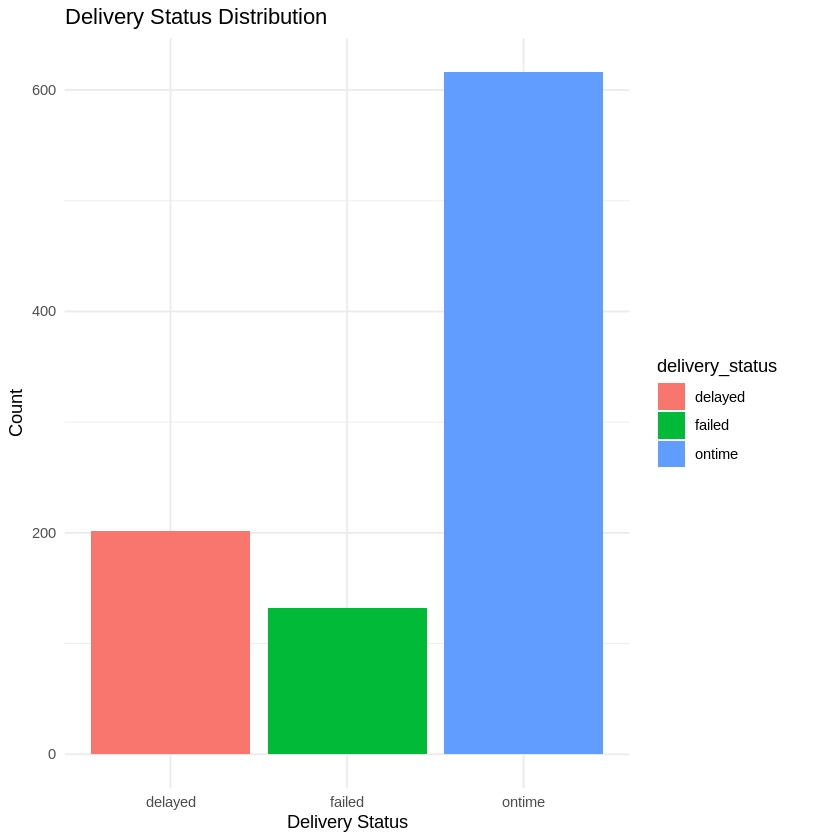

In [ ]:
# Delivery Status Performance Summary

delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    total_deliveries = n(),
    avg_distance = round(mean(route_distance_km, na.rm = TRUE), 2),
    avg_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2)
  ) %>%
  mutate(
    percentage = round(total_deliveries / sum(total_deliveries) * 100, 1)
  )

delivery_summary

# Visualisation
ggplot(deliveries,
       aes(x = delivery_status,
           fill = delivery_status)) +

geom_bar() +

labs(
  title = "Delivery Status Distribution",
  x = "Delivery Status",
  y = "Count"
) +

theme_minimal()

**Interpretation**

* OnTime deliveries account for the majority of deliveries (616, 64.8%), indicating generally good operational performance.
* OnTime deliveries also show lower average costs and fewer route overrides, suggesting more efficient delivery operations.
* Delayed deliveries (202, 21.3%) have the highest average distance, cost, and route overrides, indicating possible routing and traffic-related issues.
* Failed deliveries (132, 13.9%) remain the most critical category as they negatively affect customer satisfaction and operational reliability.
* Higher costs and increased route overrides in delayed and failed deliveries suggest areas requiring operational improvement.
* Overall, reducing delayed and failed deliveries should be a key focus for improving delivery efficiency and service quality.

### **Hub Failure Comparison**

Objective

Compare failed deliveries across hubs.

hub_name,delivery_status,total,percentage
<chr>,<chr>,<int>,<dbl>
Airport Hub,delayed,27,26.0
Airport Hub,failed,15,14.4
Airport Hub,ontime,62,59.6
Central Core,delayed,25,21.7
Central Core,failed,23,20.0
Central Core,ontime,67,58.3
East Dock,delayed,23,19.3
East Dock,failed,11,9.2
East Dock,ontime,85,71.4


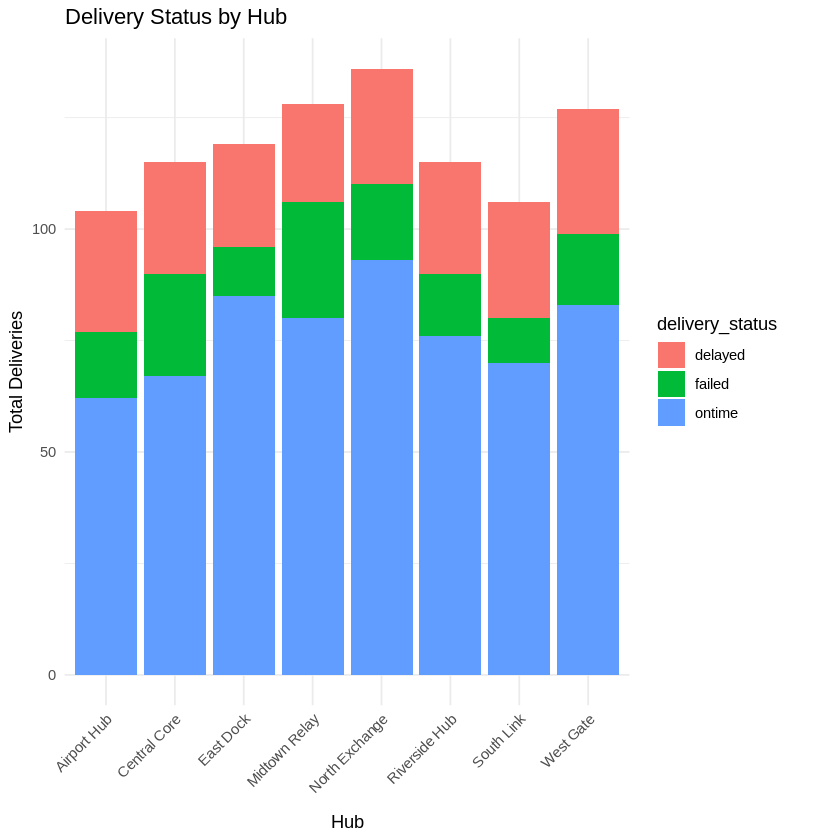

In [ ]:
hub_chart <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name, delivery_status) %>%
  summarise(total = n(), .groups = "drop") %>%
  group_by(hub_name) %>%
  mutate(percentage = round(total / sum(total) * 100, 1))

hub_chart

ggplot(hub_chart,
       aes(x = hub_name,
           y = total,
           fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(title = "Delivery Status by Hub",
       x = "Hub",
       y = "Total Deliveries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Interpretation**

* Across all hubs, **OnTime deliveries are the highest category**, ranging from 62 to 93 deliveries per hub, indicating generally good performance.
* *East Dock* and *North Exchange* show the strongest performance, with the highest OnTime counts (85 and 93 respectively) and relatively low failed deliveries.
* *Midtown Relay* and *Central Core* record the highest number of failed deliveries (26 and 23), suggesting weaker operational efficiency in these hubs.
* Delayed deliveries remain fairly consistent across hubs (around 22-28), indicating a system-wide issue rather than hub-specific variation.
* Overall, while performance is largely stable across hubs, central hubs show comparatively higher failure counts and require operational improvement.


### **Complaint Trends**

Objective

Visualise the most frequent complaint categories.

complaint_type,severity,total
<chr>,<chr>,<int>
AppIssue,High,13
AppIssue,Low,15
AppIssue,Medium,25
Billing,High,4
Billing,Low,3
Billing,Medium,9


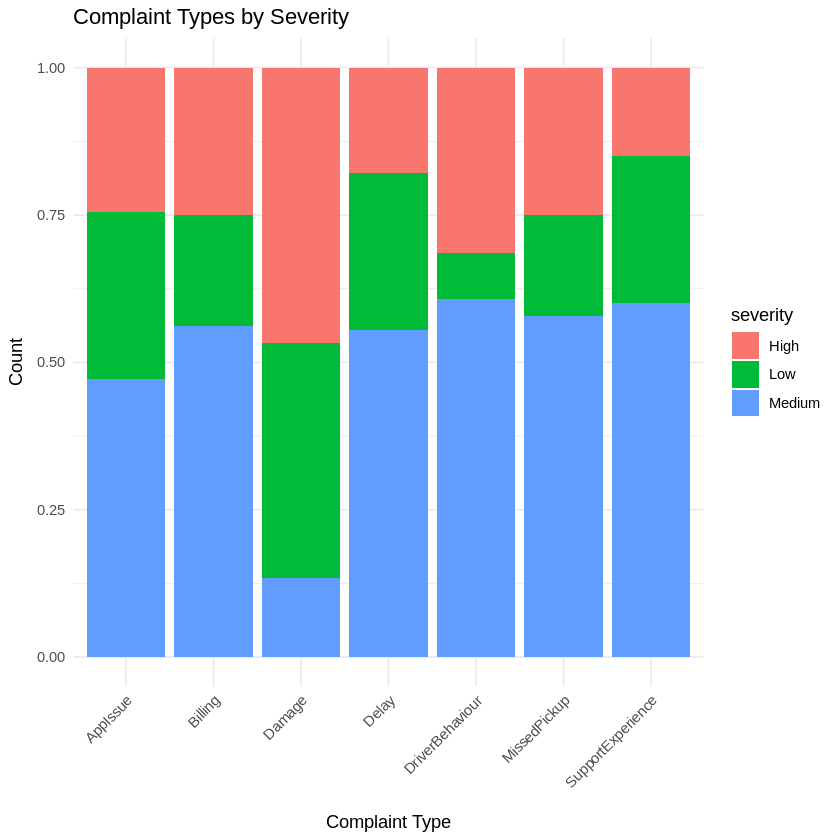

In [ ]:
# Complaint-level summary with counts
complaint_chart <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(total = n(), .groups = "drop")

head(complaint_chart)

# Visualisation: Distribution of complaints across types and severity levels
ggplot(complaints,
       aes(x = complaint_type,
           fill = severity)) +

geom_bar(position = "fill") +

labs(
  title = "Complaint Types by Severity",
  x = "Complaint Type",
  y = "Count"
) +

theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Interpretation**

* *Delay* is the most frequent complaint type across all severities, especially **Medium (56)** and **Low (27)**, indicating delivery timing is the main customer concern.
* *MissedPickup* and *DriverBehaviour* also show consistently high complaint counts, particularly at Medium severity, highlighting operational and service-related issues.
* *AppIssue* complaints are moderately distributed across all severity levels, suggesting recurring but less critical system usability problems.
* *Billing*, *Damage*, and *SupportExperience* complaints are comparatively lower in frequency, indicating these are less common issues.
* Overall, most complaints are concentrated in **Delay, MissedPickup, and DriverBehaviour categories**, suggesting core operational inefficiencies rather than isolated issues.


## **Driver Training vs Driver Rating**

Objective

Examine relationship between training score and driver rating.

 training_score  driver_rating  
 Min.   :40.60   Min.   :3.150  
 1st Qu.:68.55   1st Qu.:3.885  
 Median :75.20   Median :4.160  
 Mean   :74.91   Mean   :4.160  
 3rd Qu.:82.75   3rd Qu.:4.470  
 Max.   :99.00   Max.   :5.000  

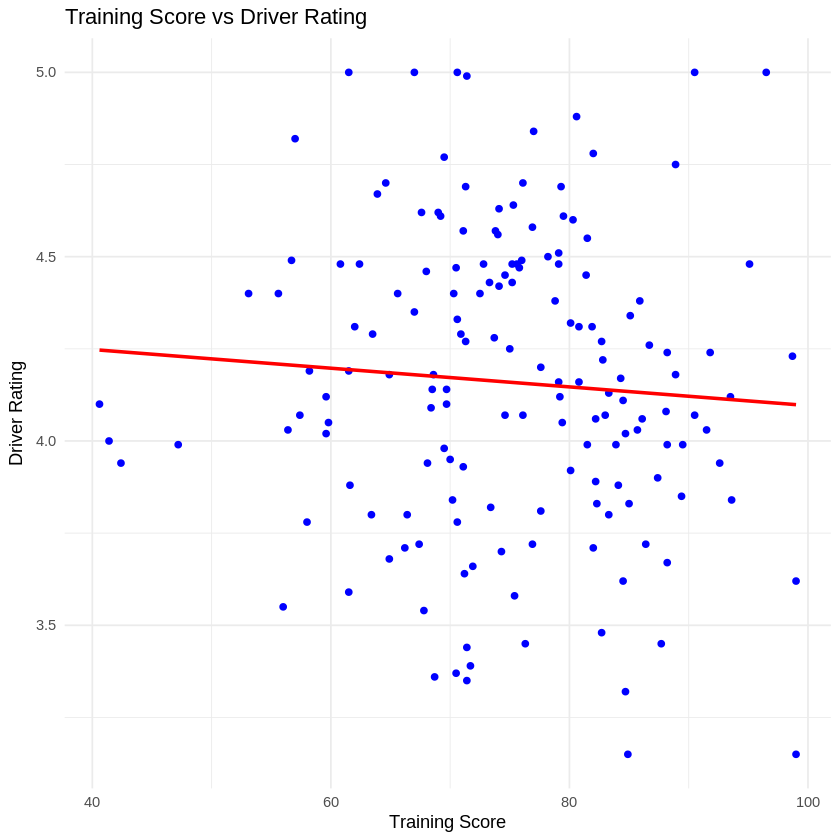

In [ ]:
# Driver-level summary
driver_chart <- drivers %>%
  select(training_score, driver_rating) %>%
  filter(!is.na(training_score),
         !is.na(driver_rating))
summary(driver_chart)

# Visualisation
ggplot(drivers,
       aes(x = training_score,
           y = driver_rating)) +

geom_point(color = "blue") +

geom_smooth(method = "lm",
            se = FALSE,
            color = "red",
            formula = y ~ x) +

labs(
  title = "Training Score vs Driver Rating",
  x = "Training Score",
  y = "Driver Rating"
) +

theme_minimal()

**Interpretation**

* The **training score ranges from 40.6 to 99.0**, showing a wide variation in driver training levels across the dataset.
* The **average training score is 74.91**, indicating that most drivers have moderately high training performance.
* Driver ratings range from **3.15 to 5.00**, with an average of **4.16**, suggesting generally good driver performance.
* The median values (training score: 75.20, rating: 4.16) are close to the mean, indicating a relatively balanced distribution without extreme skewness.
* Overall, both training scores and driver ratings are fairly strong, with some variation that may explain differences observed in performance outcomes.
* This suggests that while training score has a positive influence on driver ratings, other operational factors such as experience, workload, and route conditions may also play a role.

## **Vehicle Battery Health Distribution**

Objective

Understand vehicle battery condition across the fleet.

battery_group,vehicle_count
<fct>,<int>
0-50,3
50-60,10
60-70,22
70-80,34
80-90,29
90-100,18


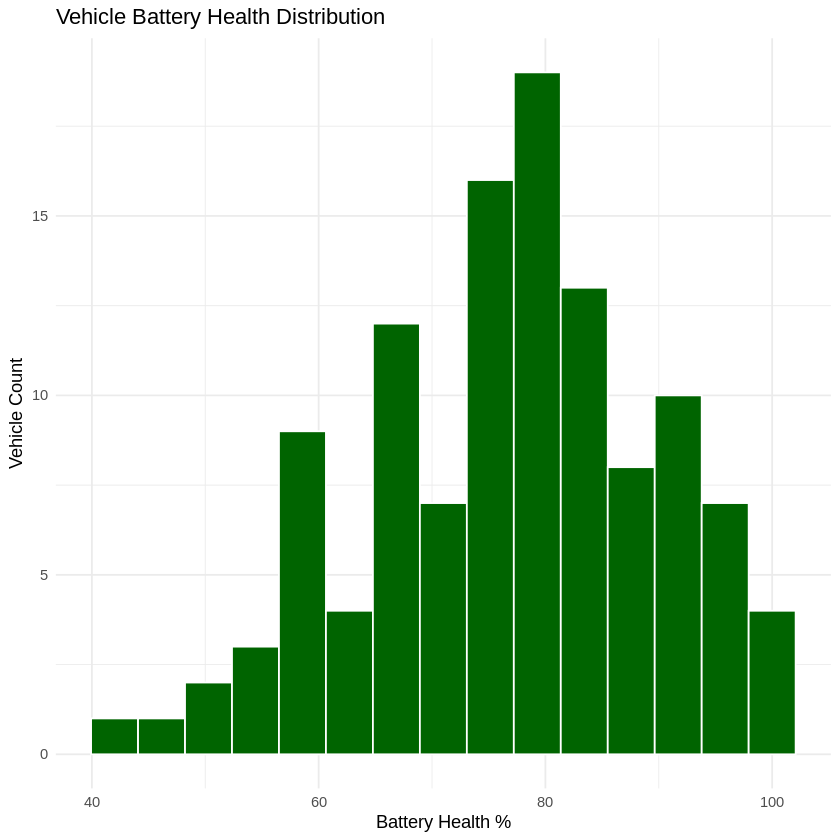

In [ ]:
# Grouped summary
vehicles %>%
  mutate(battery_group = cut(battery_health_pct,
                             breaks = c(0, 50, 60, 70, 80, 90, 100),
                             labels = c("0-50", "50-60", "60-70", "70-80", "80-90", "90-100"))) %>%
  group_by(battery_group) %>%
  summarise(vehicle_count = n(), .groups = "drop")

# Visualisation
ggplot(vehicles,
       aes(x = battery_health_pct)) +

geom_histogram(
  bins = 15,
  fill = "darkgreen",
  color = "white"
) +

labs(
  title = "Vehicle Battery Health Distribution",
  x = "Battery Health %",
  y = "Vehicle Count"
) +

theme_minimal()

**Interpretation**

* The battery health distribution shows that most vehicles are concentrated in the **70–90% range**, indicating that the fleet is generally in good operational condition.
* The highest number of vehicles falls in the **70–80% group (34 vehicles)**, followed by **80–90% (29 vehicles)**, suggesting that most vehicles maintain moderate to high battery health levels.
* A smaller proportion of vehicles are in lower ranges such as **50–60% (10 vehicles)** and **0–50% (3 vehicles)**, indicating a limited set of vehicles that may require maintenance attention.
* Overall, the fleet is **largely well-maintained**, but the presence of lower battery health vehicles suggests that **minor monitoring and servicing is still required in some cases**.


**Conclusion:**

The R analytics identified several operational patterns affecting NorthStar’s performance. Delayed and failed deliveries were associated with higher costs, longer routes, and increased manual overrides. Certain hubs showed consistently higher failure rates, while complaint analysis confirmed that delays and missed pickups are the main causes of customer dissatisfaction. Driver training showed a positive relationship with performance, and vehicle analysis indicated that most of the fleet remains in good operational condition. Overall, the findings suggest that routing inefficiencies, hub-level performance variation, and operational coordination issues are major contributors to declining service reliability